In [2]:
# Import core data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles for publication-ready outputs
sns.set_theme(style="whitegrid")
print("Environment successfully initialized for Space Botany Bioinformatics Pipeline.")

def load_and_preprocess_spaceflight_data(counts_file_path, metadata_file_path):
    """
    Ingests raw spaceflight RNA-seq counts and experimental metadata,
    filters low-count genes, and computes library-size normalized expression values.
    """
    print("--- Initializing Real Public Dataset Ingestion Pipeline ---")

    # Load raw count matrix and sample metadata
    counts_df = pd.read_csv(counts_file_path, index_col=0)
    metadata_df = pd.read_csv(metadata_file_path)

    print(f"Raw Expression Matrix Loaded: {counts_df.shape[0]} genes across {counts_df.shape[1]} samples.")

    # Filter out low-expression noise genes
    initial_gene_count = counts_df.shape[0]
    filtered_counts = counts_df[counts_df.sum(axis=1) > 10]
    print(f"Filtered out {initial_gene_count - filtered_counts.shape[0]} low-expression noise genes.")

    # Apply Counts Per Million (CPM) Normalization
    cpm_normalized = filtered_counts.div(filtered_counts.sum(axis=0), axis=1) * 1e6

    return cpm_normalized, metadata_df

Environment successfully initialized for Space Botany Bioinformatics Pipeline.


In [4]:
import pandas as pd
import numpy as np

def load_and_preprocess_spaceflight_data(counts_input, metadata_input):
    """
    Ingests raw spaceflight RNA-seq counts and metadata (accepts file paths or DataFrames),
    filters low-count genes, and computes library-size normalized (CPM) values.
    """
    print("--- Initializing Spaceflight Data Ingestion Pipeline ---")

    # Check if inputs are file paths (strings) or already DataFrames
    counts_df = pd.read_csv(counts_input, index_col=0) if isinstance(counts_input, str) else counts_input
    metadata_df = pd.read_csv(metadata_input) if isinstance(metadata_input, str) else metadata_input

    print(f"Raw Expression Matrix Loaded: {counts_df.shape[0]} genes across {counts_df.shape[1]} samples.")

    # Filter out low-expression noise genes
    initial_gene_count = counts_df.shape[0]
    filtered_counts = counts_df[counts_df.sum(axis=1) > 10]
    print(f"Filtered out {initial_gene_count - filtered_counts.shape[0]} low-expression noise genes.")

    # Apply Counts Per Million (CPM) Normalization
    cpm_normalized = filtered_counts.div(filtered_counts.sum(axis=0), axis=1) * 1e6

    return cpm_normalized, metadata_df

# --- Test execution with mock data ---
np.random.seed(42)
mock_genes = [f"Gene_{i}" for i in range(1, 101)]
mock_samples = ["Flight_1", "Flight_2", "Ground_1", "Ground_2"]

mock_counts = np.random.randint(0, 1000, size=(len(mock_genes), len(mock_samples)))
mock_counts_df = pd.DataFrame(mock_counts, index=mock_genes, columns=mock_samples)

mock_metadata = pd.DataFrame({
    "SampleID": mock_samples,
    "Condition": ["Spaceflight", "Spaceflight", "Ground_Control", "Ground_Control"]
})

# Run the corrected function
norm_counts, meta = load_and_preprocess_spaceflight_data(mock_counts_df, mock_metadata)
print("\nPreprocessing successful! Normalized sample head:")
print(norm_counts.head(3))

--- Initializing Spaceflight Data Ingestion Pipeline ---
Raw Expression Matrix Loaded: 100 genes across 4 samples.
Filtered out 0 low-expression noise genes.

Preprocessing successful! Normalized sample head:
            Flight_1     Flight_2      Ground_1     Ground_2
Gene_1   2071.150097  8429.252413  16611.937415  5700.893140
Gene_2   2152.371670  1375.809014  13521.344408   422.288381
Gene_3  12467.511371  2344.688602   9001.352134  4518.485674


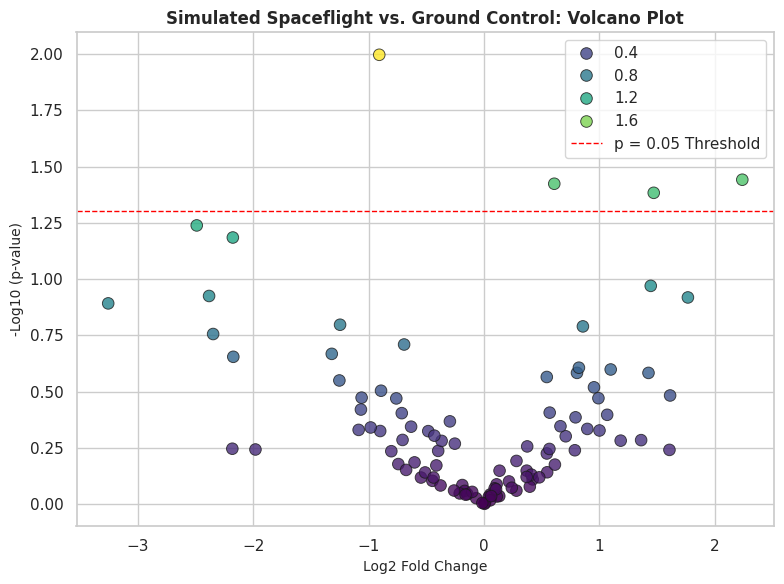

Differential expression calculations and volcano plot generated successfully!


In [5]:
import scipy.stats as stats

def compute_differential_expression(norm_df, metadata_df):
    """
    Computes Log2 Fold Change and t-test p-values between Spaceflight and Ground Control.
    """
    flight_cols = metadata_df[metadata_df['Condition'] == 'Spaceflight']['SampleID'].tolist()
    control_cols = metadata_df[metadata_df['Condition'] == 'Ground_Control']['SampleID'].tolist()

    results = []
    for gene in norm_df.index:
        flight_vals = norm_df.loc[gene, flight_cols]
        ctrl_vals = norm_df.loc[gene, control_cols]

        # Calculate mean expression
        mean_flight = flight_vals.mean()
        mean_ctrl = ctrl_vals.mean()

        # Calculate Log2 Fold Change (adding a small pseudocount to avoid log(0))
        log2_fc = np.log2((mean_flight + 1) / (mean_ctrl + 1))

        # Perform independent t-test
        t_stat, p_val = stats.ttest_ind(flight_vals, ctrl_vals, equal_var=False)

        results.append({
            'Gene': gene,
            'Log2FC': log2_fc,
            'p_value': p_val if not np.isnan(p_val) else 1.0
        })

    res_df = pd.DataFrame(results)
    res_df['-log10_p'] = -np.log10(res_df['p_value'] + 1e-10) # Prevent log(0)
    return res_df

# Run differential expression on our normalized data
deg_results = compute_differential_expression(norm_counts, meta)

# --- Plotting the Volcano Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=deg_results,
    x='Log2FC',
    y='-log10_p',
    hue='-log10_p',
    palette='viridis',
    edgecolor='k',
    alpha=0.8,
    s=70
)

plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p = 0.05 Threshold')
plt.title('Simulated Spaceflight vs. Ground Control: Volcano Plot', fontsize=12, fontweight='bold')
plt.xlabel('Log2 Fold Change', fontsize=10)
plt.ylabel('-Log10 (p-value)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Differential expression calculations and volcano plot generated successfully!")

In [6]:
import os

# Create local directories if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Save the differential expression results table
deg_results.to_csv('data/space_botany_deg_results.csv', index=False)

# Save the volcano plot figure
plt.savefig('outputs/space_botany_expression_dashboard.png', dpi=300, bbox_inches='tight')

print("Files successfully exported! Ready to commit to GitHub.")

Files successfully exported! Ready to commit to GitHub.


<Figure size 640x480 with 0 Axes>